# IT3051 – Fundamentals of Data Mining | Mini Project 2026
## Stage 6 – Model Development
**Group:** Mine4Data (DS.Y3S2.01.01) · **Project:** Airbnb Listing Price Prediction · **Input:** `data/processed/train_clean.pkl` · **Builds on:** `02_Preprocessing_Airbnb.ipynb`

This notebook develops and compares **seven machine-learning algorithms**, plus a naive mean baseline, for predicting `log_price`. It uses the fixed Stage 4 split and the Stage 4 preprocessing pipelines. All comparisons use **5-fold cross-validation on the training set only**. The test set stays locked away until the final model is chosen in Stage 7 (`04_Optimisation_Airbnb.ipynb`).

Each model is wrapped with its preprocessor in **one** sklearn `Pipeline` (see [src/modelling.py](src/modelling.py)). This means imputation, encoding, target encoding and scaling are refitted on every training fold, so no validation data leaks into the fit.

| # | Section | Stage 6 checklist item |
|---|---|---|
| 1 | Setup | – |
| 2 | Evaluation design: metrics and validation strategy | appropriate validation strategy · suitable performance metrics |
| 3 | Algorithm selection and justification | at least FOUR suitable algorithms · appropriate to the problem |
| 4 | Training and cross-validating every model | implement the algorithms |
| 5 | Systematic comparison | compare model performance systematically |
| 6 | Over- and under-fitting check | why models perform better or worse |
| 7 | Is the ranking reliable? (paired fold comparison) | compare systematically |
| 8 | Why some models perform better: learning curves, residuals, segments | understand why models perform better or worse |
| 9 | Feature-set experiment: deployable vs full | record experiments |
| 10 | Experiment record and observations → shortlist for Stage 7 | record experiments, results and observations |

## 1. Setup

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import learning_curve

from src import preprocessing as pp
from src import modelling as md

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", "{:,.3f}".format)

FIG_DIR, RESULTS_DIR = Path("figures/modelling"), Path("results")
for d in (FIG_DIR, RESULTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

SURFACE, INK, INK2, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#e4e3df"
BLUE, BLUE_LIGHT, ORANGE, AQUA, RED = "#2a78d6", "#86b6ef", "#eb6834", "#1baf7a", "#e34948"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": INK2, "text.color": INK,
    "axes.titlecolor": INK, "axes.titlesize": 11.5, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "xtick.color": INK2, "ytick.color": INK2, "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "lines.linewidth": 2, "font.size": 10, "legend.frameon": False,
    "axes.prop_cycle": plt.cycler(color=[BLUE, ORANGE, AQUA, "#eda100", "#e87ba4", "#008300", "#4a3aa7", RED]),
})
FAMILY_COLOR = {"baseline": "#b5b4ae", "linear": BLUE_LIGHT, "instance-based": "#eda100",
                "bagging ensemble": AQUA, "boosting ensemble": BLUE}

def save(fig, name):
    fig.savefig(FIG_DIR / f"{name}.png", dpi=130, bbox_inches="tight")
    plt.show()

X_train, X_test, y_train, y_test = md.load_split()
split_ids = pd.read_csv("data/processed/split_ids.csv")
print(f"Train: {len(X_train):,} rows | Test: {len(X_test):,} rows (NOT used in this notebook)")
print(f"Split file agrees with the data: {split_ids['split'].value_counts().to_dict()}")

Train: 59,287 rows | Test: 14,822 rows (NOT used in this notebook)
Split file agrees with the data: {'train': 59287, 'test': 14822}


## 2. Evaluation design: metrics and validation strategy

### Metrics
The models predict `log_price`, so the **primary metric is RMSE on the log scale**. The other metrics are reported alongside it for two different readers.

| Metric | Scale | Why we report it |
|---|---|---|
| **RMSE (log)**, *primary* | log $ | The quantity the models minimise. An error of 0.1 in log units ≈ 10% of the price, so it measures **relative** error, which is fair to both a $50 room and a $500 house. Squaring punishes large misses, which are the ones that cost a host bookings or money. |
| MAE (log) | log $ | Robust to a few very large misses; a check that RMSE is not driven by a handful of rows. |
| R² | log $ | Share of price variance explained; comparable with the Stage 4 sanity check (0.70 for untuned HistGB). |
| MAE ($), median AE ($) | US$ / night | What a host understands: "on average the suggestion is off by $X". The median is less affected by luxury listings. |
| MAPE (%) and **share within ±25%** | % | Business view: how often the suggested price is close enough to be useful. |

`exp(predicted log price)` estimates the **median** price for listings like this one. That is the "typical price" we want to recommend to a host.

### Validation strategy
- **5-fold cross-validation on the 59,287 training listings only** (`KFold`, shuffled, `random_state = 42`). The test set (14,822 listings) is **not touched** until the final model has been chosen in Stage 7. It then gives one honest, unbiased estimate.
- **The same five folds are used for every model** (`md.CV`). The comparison is therefore *paired*: every model is scored on exactly the same validation listings.
- **Preprocessing is refitted inside every fold** because it is part of the pipeline. Target encoding, imputation and scaling never see the validation fold.
- **Why k-fold rather than a single validation split?** Five scores per model show both the mean *and* the variability. With 59k rows each fold still has ~11.9k validation listings. **Why not a time-based split?** The data is a single cross-sectional snapshot (2017) and the task is "price this listing now", not forecasting. Shuffled k-fold is therefore appropriate.
- The folds are shuffled at random (not stratified). The check below shows that every fold already has almost the same price distribution.

In [2]:
fold_check = pd.DataFrame([
    {"fold": k, "validation rows": len(va), "mean log_price": y_train.iloc[va].mean(), "std log_price": y_train.iloc[va].std(),
     "NYC share": (X_train["city"].iloc[va] == "NYC").mean(), "entire-home share": (X_train["room_type"].iloc[va] == "Entire home/apt").mean()}
    for k, (_, va) in enumerate(md.CV.split(X_train), start=1)]).set_index("fold")
fold_check

,validation rows,mean log_price,std log_price,NYC share,entire-home share
fold,,,,,
1,11858,4.788,0.716,0.434,0.560
2,11858,4.786,0.722,0.443,0.561
3,11857,4.776,0.719,0.440,0.555
4,11857,4.772,0.707,0.437,0.554
5,11857,4.790,0.732,0.434,0.562


## 3. Algorithm selection and justification

We compare **seven algorithms from four different families**, plus a mean baseline. A family is a different assumption about how price depends on the features. Comparing families (not seven variations of one idea) tells us *what kind* of structure the data has.

| Model | Family | Why it suits this problem (EDA / Stage 4 evidence) | Expected weakness | Preprocessing |
|---|---|---|---|---|
| **Mean baseline** | – | Predicts the training mean for everyone. Any useful model must clearly beat it. | Ignores all features | – |
| **Linear Regression** | linear | The simplest, fully interpretable model. EDA showed strong, roughly monotonic effects on the log scale (capacity, room type). | No interactions; unstable with correlated size features (EDA §10) | `linear`: winsorised, scaled, first dummy dropped |
| **Ridge** | linear (L2) | The L2 penalty shrinks and stabilises correlated coefficients (`accommodates`, `beds`, `bedrooms`: r ≈ 0.7–0.8, EDA §10). | Still additive and linear | `linear` |
| **Lasso** | linear (L1) | The L1 penalty sets weak coefficients to exactly 0. This is **embedded feature selection** across 87 columns (53 amenity flags). | Linear; picks one of several correlated features | `linear` |
| **K-Nearest Neighbours** | instance-based | Mirrors how hosts price in practice: "look at similar listings nearby" (comparables). Non-parametric. | All features weighted equally in the distance; 87 dimensions dilute distances; slow to predict | `linear` (scaling is essential for distances) |
| **Random Forest** | bagging ensemble | Captures non-linear effects and interactions (EDA §10: the effect of size depends on room type and city). Robust to outliers and needs no scaling. | Large model; averaging limits extreme predictions | `tree`: unscaled, all dummies |
| **HistGradientBoosting** | boosting ensemble | Each tree corrects the previous trees' errors. Histogram binning makes it fast on 59k rows. | More hyper-parameters; can over-fit if not tuned | `tree` |
| **XGBoost** | boosting ensemble | Regularised boosting (shrinkage, L1/L2 on leaf weights, row and column subsampling). It is a strong reference on tabular data. | Many hyper-parameters | `tree` |

**Settings in this notebook:** library defaults, so that we compare the *algorithms* and not our tuning effort. There are two documented exceptions. Lasso uses `alpha = 0.001`, because the default of 1.0 removes every feature. Random Forest uses `max_features = 1/3`, Breiman's standard choice for regression. Stage 7 tunes every model.

**The feature set is `listing`:** the deployable features a host can type into the form (EDA §16). The `full` set is examined separately in §9.

In [3]:
catalogue = pd.DataFrame([(name, family, kind, type(factory()).__name__) for name, (kind, family, factory) in md.MODELS.items()],
                         columns=["model", "family", "preprocessing", "estimator class"]).set_index("model")
catalogue

,family,preprocessing,estimator class
model,,,
Mean baseline,baseline,tree,DummyRegressor
Linear Regression,linear,linear,LinearRegression
Ridge,linear,linear,Ridge
Lasso,linear,linear,Lasso
KNN,instance-based,linear,KNeighborsRegressor
Random Forest,bagging ensemble,tree,RandomForestRegressor
HistGradientBoosting,boosting ensemble,tree,HistGradientBoostingRegressor
XGBoost,boosting ensemble,tree,XGBRegressor


## 4. Training and cross-validating every model
`md.cross_validate_model` fits a **fresh copy** of the full pipeline (preprocessing + model) on four folds and predicts the fifth, five times. It records validation metrics, training-fold metrics (for §6), timings and the out-of-fold predictions (for §8).

In [4]:
results, oof = {}, {}
for name in md.MODELS:
    t0 = time.perf_counter()
    folds, oof[name] = md.cross_validate_model(md.make_pipeline(name, "listing"), X_train, y_train)
    results[name] = folds
    print(f"{name:22s} CV RMSE {folds['RMSE (log)'].mean():.4f} ± {folds['RMSE (log)'].std():.4f} | "
          f"R² {folds['R²'].mean():.3f} | MAE ${folds['MAE ($)'].mean():6.1f} | {time.perf_counter() - t0:5.0f} s")

fold_table = pd.concat({n: f.set_index("fold") for n, f in results.items()}, names=["model", "fold"])
fold_table.to_csv(RESULTS_DIR / "stage6_cv_folds.csv")

Mean baseline          CV RMSE 0.7191 ± 0.0090 | R² -0.000 | MAE $  88.6 |    41 s


Linear Regression      CV RMSE 0.4168 ± 0.0069 | R² 0.664 | MAE $  53.4 |    43 s


Ridge                  CV RMSE 0.4172 ± 0.0070 | R² 0.663 | MAE $  53.5 |    43 s


Lasso                  CV RMSE 0.4183 ± 0.0068 | R² 0.662 | MAE $  53.6 |    57 s


KNN                    CV RMSE 0.4472 ± 0.0079 | R² 0.613 | MAE $  56.4 |   160 s


Random Forest          CV RMSE 0.3931 ± 0.0077 | R² 0.701 | MAE $  50.0 |   302 s


HistGradientBoosting   CV RMSE 0.3935 ± 0.0072 | R² 0.701 | MAE $  50.0 |    78 s


XGBoost                CV RMSE 0.3929 ± 0.0067 | R² 0.701 | MAE $  49.9 |    50 s


## 5. Systematic comparison

In [5]:
summary = pd.DataFrame({n: md.summarise_folds(f) for n, f in results.items()}).T.sort_values("RMSE (log)")
summary.insert(0, "family", [md.MODELS[n][1] for n in summary.index])
cols = ["family", "RMSE (log)", "RMSE std", "MAE (log)", "R²", "MAE ($)", "MedAE ($)", "MAPE (%)",
        "within ±25% (%)", "fit time (s)", "predict time (s)"]
summary = summary[cols]
summary.to_csv(RESULTS_DIR / "stage6_cv_summary.csv")
summary.style.format({c: "{:.4f}" for c in ["RMSE (log)", "RMSE std", "MAE (log)"]} |
                     {"R²": "{:.3f}", "MAE ($)": "${:.1f}", "MedAE ($)": "${:.1f}", "MAPE (%)": "{:.1f}",
                      "within ±25% (%)": "{:.1f}", "fit time (s)": "{:.1f}", "predict time (s)": "{:.2f}"}
                     ).background_gradient(subset=["RMSE (log)"], cmap="Blues_r").background_gradient(subset=["R²"], cmap="Blues")

,family,RMSE (log),RMSE std,MAE (log),R²,MAE ($),MedAE ($),MAPE (%),within ±25% (%),fit time (s),predict time (s)
XGBoost,boosting ensemble,0.3929,0.0067,0.2827,0.701,$49.9,$22.7,29.6,57.0,6.9,0.64
Random Forest,bagging ensemble,0.3931,0.0077,0.2810,0.701,$50.0,$22.3,29.1,57.3,50.3,2.17
HistGradientBoosting,boosting ensemble,0.3935,0.0072,0.2837,0.701,$50.0,$22.6,29.5,56.8,12.4,0.68
Linear Regression,linear,0.4168,0.0069,0.3034,0.664,$53.4,$24.6,31.6,53.6,5.6,0.69
Ridge,linear,0.4172,0.0070,0.3039,0.663,$53.5,$24.6,31.6,53.5,5.3,0.76
Lasso,linear,0.4183,0.0068,0.3045,0.662,$53.6,$24.6,31.7,53.3,8.2,0.75
KNN,instance-based,0.4472,0.0079,0.3273,0.613,$56.4,$26.9,34.9,50.6,6.4,5.32
Mean baseline,baseline,0.7191,0.0090,0.5625,-0.000,$88.6,$50.7,62.8,28.8,5.3,0.66


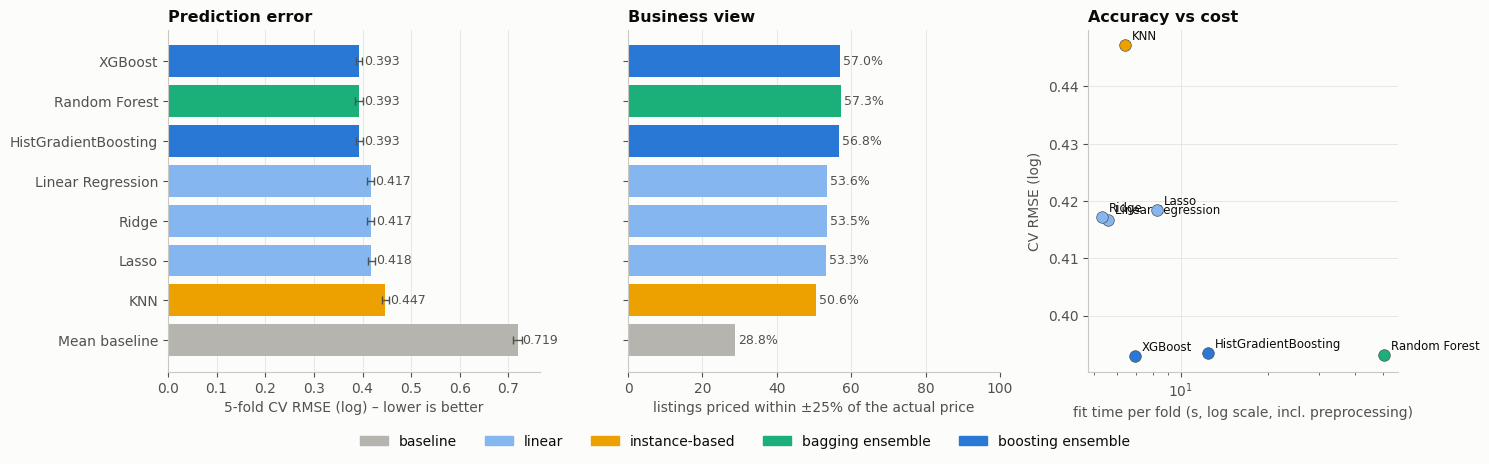

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.2, 1.2, 1]})
order = summary.index[::-1]
colors = [FAMILY_COLOR[summary.loc[n, "family"]] for n in order]

ax = axes[0]
ax.barh(order, summary.loc[order, "RMSE (log)"], xerr=summary.loc[order, "RMSE std"], color=colors,
        error_kw={"ecolor": INK2, "capsize": 3, "lw": 1})
for i, n in enumerate(order):
    ax.text(summary.loc[n, "RMSE (log)"] + .01, i, f"{summary.loc[n, 'RMSE (log)']:.3f}", va="center", fontsize=9, color=INK2)
ax.set_xlabel("5-fold CV RMSE (log) – lower is better"); ax.set_title("Prediction error"); ax.grid(axis="y", visible=False)

ax = axes[1]
ax.barh(order, summary.loc[order, "within ±25% (%)"], color=colors)
for i, n in enumerate(order):
    ax.text(summary.loc[n, "within ±25% (%)"] + .8, i, f"{summary.loc[n, 'within ±25% (%)']:.1f}%", va="center", fontsize=9, color=INK2)
ax.set_xlabel("listings priced within ±25% of the actual price"); ax.set_title("Business view"); ax.set_yticklabels([])
ax.set_xlim(0, 100); ax.grid(axis="y", visible=False)

ax = axes[2]
for n in summary.index.drop("Mean baseline"):
    ax.scatter(summary.loc[n, "fit time (s)"], summary.loc[n, "RMSE (log)"], s=70, color=FAMILY_COLOR[summary.loc[n, "family"]],
               edgecolor=INK2, lw=.5, zorder=3)
    ax.annotate(n, (summary.loc[n, "fit time (s)"], summary.loc[n, "RMSE (log)"]), xytext=(5, 4), textcoords="offset points", fontsize=8.5)
ax.set_xscale("log"); ax.set_xlabel("fit time per fold (s, log scale, incl. preprocessing)"); ax.set_ylabel("CV RMSE (log)")
ax.set_title("Accuracy vs cost")
handles = [plt.Rectangle((0, 0), 1, 1, color=c) for c in FAMILY_COLOR.values()]
fig.legend(handles, FAMILY_COLOR.keys(), loc="lower center", ncol=5, bbox_to_anchor=(.5, -.06))
fig.tight_layout()
save(fig, "05_model_comparison")

**Reading the result**
- **Every model beats the mean baseline by a wide margin** (RMSE 0.719 → 0.447 or better). The listing features carry real price signal for all four families.
- **The tree ensembles are best:** XGBoost 0.3929, Random Forest 0.3931 and HistGradientBoosting 0.3935 (R² = 0.701 for all three). They price **57% of listings within ±25%** of the actual price (linear models: 53.5%) and reduce the average dollar error from $53.4 to **$49.9 per night**.
- **The three ensembles are within 0.0006 of each other.** That is less than a tenth of the fold-to-fold standard deviation (≈ 0.007), so with default settings they are **tied** (§7 confirms this). Tuning in Stage 7 has to separate them.
- **The linear models form a clear second tier** (RMSE ≈ 0.417, R² ≈ 0.664). OLS, Ridge and Lasso are almost identical. With 59k rows and 87 features, OLS is barely over-fitting (§6), so regularisation has little to correct.
- **KNN is the weakest real model** (0.447). Its distance gives equal weight to all 87 scaled features, and more than half of them are binary amenity flags, so "similar" listings are often not similar in the ways that matter for price (size, room type, location). It is also the slowest to **predict** (5.3 s per fold vs < 1 s), because every prediction is compared with all ~47k training listings.
- **Cost:** Random Forest takes ~7× longer to train than XGBoost (50 s vs 7 s per fold, including ~5 s of preprocessing) for the same accuracy.

## 6. Over- and under-fitting check
A model that scores much better on the data it was trained on than on the held-out fold is **over-fitting** (memorising). A model that is poor on both is **under-fitting** (too simple).

,train R²,CV R²,train RMSE,CV RMSE,gap (train − CV R²),diagnosis
XGBoost,0.790,0.701,0.330,0.393,0.088,mild over-fitting
Random Forest,0.939,0.701,0.177,0.393,0.238,strong over-fitting
HistGradientBoosting,0.731,0.701,0.373,0.393,0.031,well balanced / under-fitting
Linear Regression,0.669,0.664,0.414,0.417,0.005,well balanced / under-fitting
Ridge,0.669,0.663,0.414,0.417,0.005,well balanced / under-fitting
Lasso,0.667,0.662,0.415,0.418,0.005,well balanced / under-fitting
KNN,0.745,0.613,0.363,0.447,0.132,mild over-fitting
Mean baseline,0.000,-0.000,0.719,0.719,0.000,no signal (baseline)


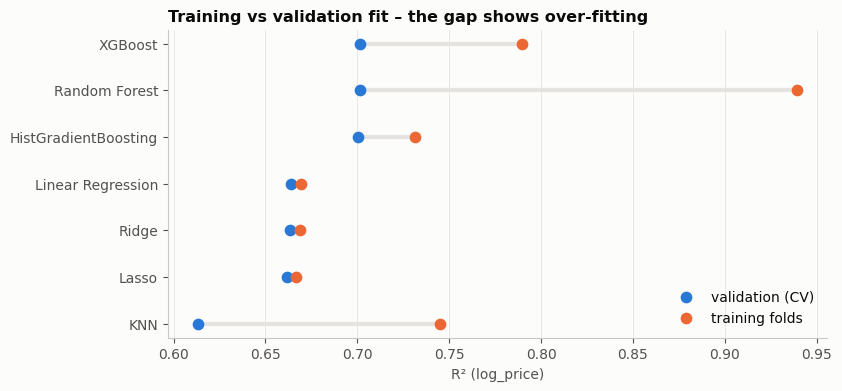

In [7]:
fit_gap = pd.DataFrame({
    "train R²": fold_table.groupby("model")["train R²"].mean(),
    "CV R²": fold_table.groupby("model")["R²"].mean(),
    "train RMSE": fold_table.groupby("model")["train RMSE (log)"].mean(),
    "CV RMSE": fold_table.groupby("model")["RMSE (log)"].mean()}).loc[summary.index]
fit_gap["gap (train − CV R²)"] = fit_gap["train R²"] - fit_gap["CV R²"]
fit_gap["diagnosis"] = np.select(
    [fit_gap["CV R²"] < 0.1, fit_gap["gap (train − CV R²)"] > 0.15, fit_gap["gap (train − CV R²)"] > 0.05],
    ["no signal (baseline)", "strong over-fitting", "mild over-fitting"], "well balanced / under-fitting")
display(fit_gap)

fig, ax = plt.subplots(figsize=(8.5, 4))
models = fit_gap.index.drop("Mean baseline")[::-1]
for i, n in enumerate(models):
    ax.plot([fit_gap.loc[n, "CV R²"], fit_gap.loc[n, "train R²"]], [i, i], color=GRID, lw=3, zorder=1)
ax.scatter(fit_gap.loc[models, "CV R²"], range(len(models)), color=BLUE, s=55, label="validation (CV)", zorder=3)
ax.scatter(fit_gap.loc[models, "train R²"], range(len(models)), color=ORANGE, s=55, label="training folds", zorder=3)
ax.set_yticks(range(len(models))); ax.set_yticklabels(models); ax.set_xlabel("R² (log_price)")
ax.set_title("Training vs validation fit – the gap shows over-fitting"); ax.legend(loc="lower right"); ax.grid(axis="y", visible=False)
save(fig, "06_train_vs_validation")

**Reading the result**
- **Linear models under-fit (high bias).** Their training and validation R² are almost equal (gap 0.005). Even on the data they were fitted to, an additive straight-line formula cannot explain more than ~67% of price variance. Regularising them further cannot help. Only a more flexible model can.
- **Random Forest over-fits strongly:** training R² 0.939 vs 0.701 on validation. Fully grown trees memorise individual training listings. Averaging 200 of them still generalises as well as boosting, but the gap shows there is room for regularisation (`min_samples_leaf`, `max_depth`) in Stage 7. It also makes the model very large.
- **XGBoost shows mild over-fitting (gap 0.088). HistGradientBoosting has the smallest gap (0.031)** because its defaults include early stopping and a minimum leaf size of 20.
- **KNN (gap 0.132):** with k = 5, each training listing is its own nearest neighbour, which inflates the training score. A larger k should help (Stage 7).

## 7. Is the ranking reliable? Paired fold-by-fold comparison
Every model was scored on the **same five validation folds**, so we can compare them fold by fold. If the best model wins on every fold, and the margin is much larger than the fold-to-fold noise, the ranking is not a lucky split.

,mean ΔRMSE vs best,std of Δ across folds,folds where XGBoost is better
model,,,
Random Forest,0.000,0.002,2
HistGradientBoosting,0.001,0.001,3
Linear Regression,0.024,0.002,5
Ridge,0.024,0.002,5
Lasso,0.025,0.002,5
KNN,0.054,0.002,5
Mean baseline,0.326,0.004,5


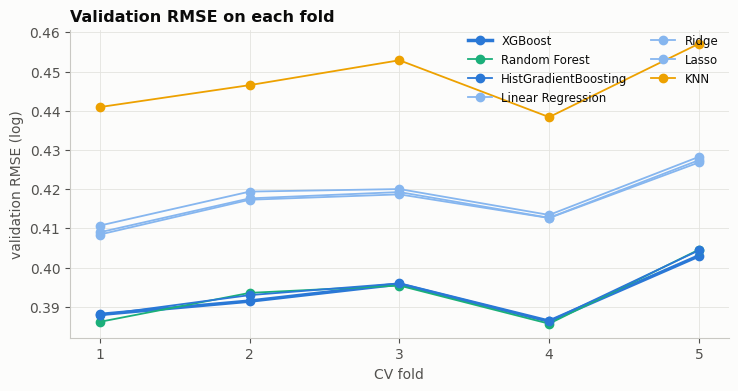

In [8]:
rmse_by_fold = fold_table["RMSE (log)"].unstack("model")[summary.index]
best = summary.index[0]
paired = pd.DataFrame({
    "mean ΔRMSE vs best": (rmse_by_fold.sub(rmse_by_fold[best], axis=0)).mean(),
    "std of Δ across folds": (rmse_by_fold.sub(rmse_by_fold[best], axis=0)).std(),
    f"folds where {best} is better": rmse_by_fold.gt(rmse_by_fold[best], axis=0).sum(),
}).drop(best)
display(paired)

fig, ax = plt.subplots(figsize=(8.5, 4))
for n in summary.index.drop("Mean baseline"):
    ax.plot(rmse_by_fold.index, rmse_by_fold[n], marker="o", color=FAMILY_COLOR[summary.loc[n, "family"]],
            lw=2.5 if n == best else 1.3, label=n)
ax.set_xticks(rmse_by_fold.index); ax.set_xlabel("CV fold"); ax.set_ylabel("validation RMSE (log)")
ax.set_title("Validation RMSE on each fold"); ax.legend(ncol=2, fontsize=8.5, loc="upper right", bbox_to_anchor=(1, 1.02))
save(fig, "07_rmse_by_fold")

**Reading the result**
- **Every tree ensemble beats every linear model and KNN on all 5 folds.** The margin is ≈ 0.024 (linear) and ≈ 0.054 (KNN), while the fold-to-fold std of that margin is only 0.002. The gap between the families is **systematic, not a lucky split**.
- **Among the three ensembles there is no reliable winner at default settings.** XGBoost beats Random Forest on only 2 of 5 folds and HistGradientBoosting on 3 of 5, by 0.0002–0.0006 on average. The folds share training data, so a formal paired t-test would overstate confidence. We therefore rely on the consistency across folds shown here.

## 8. Why do some models perform better?
### 8a. Learning curves: more data or a more flexible model?
A learning curve refits the model on growing portions of each training fold. If the training and validation curves **meet at a high error**, the model is too simple (**bias**): more data will not help, and only a more flexible model will. If there is a **large gap** that shrinks as data grows, the model is flexible (**variance**) and benefits from more data.

Ridge                       XGBoost                   
  train rows train RMSE CV RMSE train rows train RMSE CV RMSE
0       4742      0.407   0.431       4742      0.194   0.435
1      11857      0.410   0.423      11857      0.261   0.416
2      23714      0.413   0.420      23714      0.301   0.403
3      47429      0.414   0.417      47429      0.329   0.393

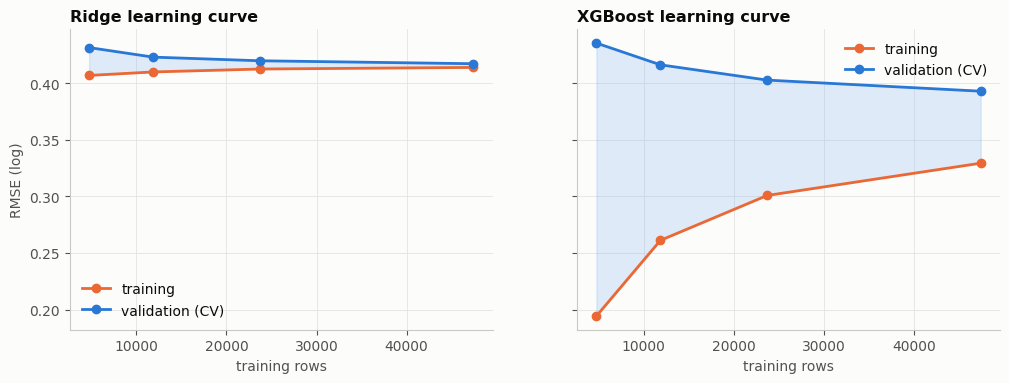

In [9]:
sizes = [0.1, 0.25, 0.5, 1.0]
curves = {}
for name in ["Ridge", "XGBoost"]:
    n_abs, tr_scores, va_scores = learning_curve(md.make_pipeline(name, "listing"), X_train, y_train, cv=md.CV,
                                                 train_sizes=sizes, scoring="neg_root_mean_squared_error")
    curves[name] = pd.DataFrame({"train rows": n_abs, "train RMSE": -tr_scores.mean(1), "CV RMSE": -va_scores.mean(1)})
display(pd.concat(curves, axis=1))

fig, axes = plt.subplots(1, 2, figsize=(12, 3.9), sharey=True)
for ax, (name, c) in zip(axes, curves.items()):
    ax.plot(c["train rows"], c["train RMSE"], marker="o", color=ORANGE, label="training")
    ax.plot(c["train rows"], c["CV RMSE"], marker="o", color=BLUE, label="validation (CV)")
    ax.fill_between(c["train rows"], c["train RMSE"], c["CV RMSE"], color=BLUE_LIGHT, alpha=.25)
    ax.set_title(f"{name} learning curve"); ax.set_xlabel("training rows"); ax.legend()
axes[0].set_ylabel("RMSE (log)")
save(fig, "08a_learning_curves")

**Reading the result**
- **Ridge is limited by bias.** Its training and validation curves have already met at ~0.414–0.417 with 12k rows. Four times more data improves CV RMSE only from 0.431 to 0.417. The limit is the **linear form itself**: it cannot express interactions. For example, an extra guest is worth a different amount in a private room than in an entire home, or in NYC than in Chicago (EDA §10).
- **XGBoost is limited by variance and uses extra data well.** Validation error keeps falling (0.435 → 0.393) as the training set grows. Training error rises (0.194 → 0.329) as the model can no longer memorise, and the gap narrows. With only 4.7k rows XGBoost is **no better** than Ridge (0.435 vs 0.431). With 47k rows it is clearly better.
- **This is the main reason the tree ensembles win here:** the data contains non-linear effects and interactions, and there are enough listings (59k) for flexible models to learn them without over-fitting. More data would help the tree models further, but not the linear ones.

### 8b. Where do the errors come from? Residuals across the price range
We use the out-of-fold predictions: every training listing is predicted by a model that never saw it.

,$10–50,$50–65,$65–80,$80–95,$95–112,$112–135,$135–165,$165–200,$200–300,$300–1999
Linear Regression,+0.377,+0.161,+0.093,+0.067,+0.060,+0.016,-0.029,-0.101,-0.199,-0.541
KNN,+0.418,+0.206,+0.125,+0.075,+0.056,+0.002,-0.051,-0.124,-0.225,-0.542
XGBoost,+0.334,+0.147,+0.084,+0.053,+0.048,+0.004,-0.039,-0.097,-0.176,-0.449


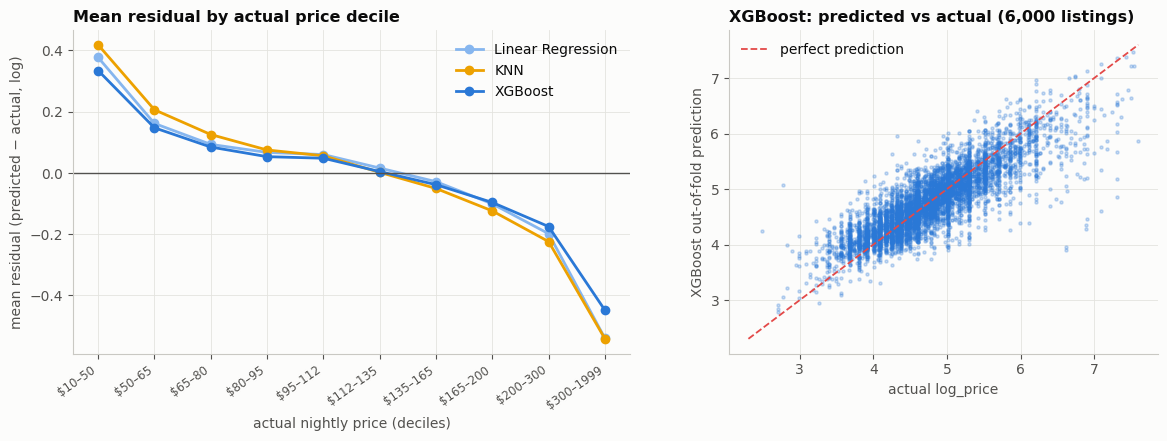

In [10]:
best_linear = summary[summary["family"] == "linear"].index[0]
bands = pd.qcut(np.exp(y_train), 10)
band_labels = [f"${iv.left:.0f}–{iv.right:.0f}" for iv in bands.cat.categories]
resid = pd.DataFrame({m: oof[m] - y_train for m in [best_linear, "KNN", best]})
by_band = resid.groupby(bands, observed=True).mean()
by_band.index = band_labels
display(by_band.T.style.format("{:+.3f}").background_gradient(cmap="RdBu", vmin=-.5, vmax=.5, axis=None))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), gridspec_kw={"width_ratios": [1.3, 1]})
ax = axes[0]
for m, col in zip(by_band.columns, [BLUE_LIGHT, "#eda100", BLUE]):
    ax.plot(range(10), by_band[m], marker="o", color=col, label=m)
ax.axhline(0, color=INK2, lw=1)
ax.set_xticks(range(10)); ax.set_xticklabels(band_labels, rotation=35, ha="right", fontsize=8.5)
ax.set_xlabel("actual nightly price (deciles)"); ax.set_ylabel("mean residual (predicted − actual, log)")
ax.set_title("Mean residual by actual price decile"); ax.legend()

ax = axes[1]
sample = y_train.sample(6000, random_state=md.RANDOM_STATE).index
ax.scatter(y_train[sample], oof[best][sample], s=5, alpha=.25, color=BLUE)
lims = [y_train.min(), y_train.max()]
ax.plot(lims, lims, color=RED, lw=1.3, ls="--", label="perfect prediction")
ax.set_xlabel("actual log_price"); ax.set_ylabel(f"{best} out-of-fold prediction"); ax.set_title(f"{best}: predicted vs actual (6,000 listings)")
ax.legend(loc="upper left")
save(fig, "08b_residuals_by_price")

**Reading the result**
- **All models pull extreme prices toward the middle (regression toward the mean).** In the cheapest decile ($10–50) they over-predict by +0.33 to +0.42 log units (≈ 40–50% too high). In the most expensive decile ($300+) they under-predict by −0.45 to −0.54 (≈ 36–42% too low). Two listings that look the same on paper (same size, room type and area) can differ in price because of things the dataset does not record: photos, decor, view, exact building, host strategy. The model can only predict the typical price for that profile.
- **XGBoost has the smallest bias at both ends** (top decile −0.45 vs −0.54 for Linear Regression and KNN). Its non-linearity captures more of the luxury premium.
- **Implication for the system (Stage 9–10):** in the $50–200 range, where most listings are, XGBoost's mean residual is within ±0.15. The tool should present the prediction as a **typical price with a range**, and it will be less reliable for budget and luxury listings.

### 8c. Which kinds of listings are hardest to price?

In [11]:
seg = pd.DataFrame({"city": X_train["city"], "room_type": X_train["room_type"], "y": y_train,
                    best: oof[best], best_linear: oof[best_linear]})
def seg_errors(col):
    rows = []
    for level, g in seg.groupby(col):
        rows.append({col: level, "listings": len(g),
                     f"{best} MAPE (%)": md.regression_metrics(g["y"], g[best])["MAPE (%)"],
                     f"{best_linear} MAPE (%)": md.regression_metrics(g["y"], g[best_linear])["MAPE (%)"],
                     f"{best} RMSE": md.regression_metrics(g["y"], g[best])["RMSE (log)"]})
    return pd.DataFrame(rows).set_index(col)
display(seg_errors("city"))
display(seg_errors("room_type"))

,listings,XGBoost MAPE (%),Linear Regression MAPE (%),XGBoost RMSE
city,,,,
Boston,2808,29.035,31.759,0.382
Chicago,2972,31.485,32.464,0.401
DC,4551,42.973,44.808,0.557
LA,17882,28.153,30.942,0.377
NYC,25940,27.152,29.028,0.359
SF,5134,33.896,34.301,0.434


,listings,XGBoost MAPE (%),Linear Regression MAPE (%),XGBoost RMSE
room_type,,,,
Entire home/apt,33112,29.775,31.842,0.386
Private room,24428,28.732,30.321,0.394
Shared room,1747,37.016,44.043,0.504


**Reading the result**
- **By city:** NYC (27% MAPE) and LA (28%) are the easiest. They are the two largest cities and supply 74% of the training data. **DC is the hardest (43% MAPE, RMSE 0.557)**, followed by SF (34%). These cities have fewer training listings, so neighbourhood encodings and location effects are estimated less precisely.
- **By room type:** shared rooms are the hardest (37% MAPE). They are only 3% of the data (1,747 listings), and here XGBoost's advantage over the linear model is largest (37% vs 44%).
- **XGBoost is better than Linear Regression in every segment**, so its advantage is not limited to one city or room type.

## 9. Feature-set experiment: deployable (`listing`) vs `full`
The `full` set adds host and booking-history features (number of reviews, review score, response rate, listing age, host tenure). A **brand-new listing does not have these** (EDA §16), so they cannot be used in the deployed pricing tool. We measure how much they are worth for a representative model of each strong family. The result is an "upper bound for existing hosts".

In [12]:
fs_rows = []
for name in [best_linear, "Random Forest", "HistGradientBoosting", "XGBoost"]:
    folds_full, _ = md.cross_validate_model(md.make_pipeline(name, "full"), X_train, y_train)
    full = md.summarise_folds(folds_full)
    lst = summary.loc[name]
    fs_rows.append({"model": name, "listing RMSE": lst["RMSE (log)"], "full RMSE": full["RMSE (log)"],
                    "listing R²": lst["R²"], "full R²": full["R²"], "ΔR² (full − listing)": full["R²"] - lst["R²"],
                    "listing MAE ($)": lst["MAE ($)"], "full MAE ($)": full["MAE ($)"]})
feature_sets = pd.DataFrame(fs_rows).set_index("model")
feature_sets.to_csv(RESULTS_DIR / "stage6_feature_sets.csv")
feature_sets

,listing RMSE,full RMSE,listing R²,full R²,ΔR² (full − listing),listing MAE ($),full MAE ($)
model,,,,,,,
Linear Regression,0.417,0.407,0.664,0.679,0.015,53.419,52.632
Random Forest,0.393,0.379,0.701,0.722,0.021,50.015,48.539
HistGradientBoosting,0.393,0.378,0.701,0.723,0.023,50.002,48.257
XGBoost,0.393,0.377,0.701,0.724,0.023,49.937,48.169


**Reading the result**
- **The full feature set improves every model by ΔR² = 0.015–0.023** (XGBoost RMSE 0.393 → 0.377, MAE $49.9 → $48.2). Review and host history contain real but modest information: about **$1.8 per night** of average error.
- **Decision: the final model uses the deployable `listing` features.** A new host has no reviews, response rate or listing age. A model that needs them either cannot price new listings or silently fills in misleading values. The `full` result is reported as the upper bound that could be achieved for existing hosts.
- The gain is similar for all four models, so the choice of feature set does not change the ranking of algorithms.

## 10. Experiment record and observations

In [13]:
log = summary[["family", "RMSE (log)", "RMSE std", "R²", "MAE ($)", "within ±25% (%)", "fit time (s)"]].copy()
log.insert(1, "feature set", "listing")
log.insert(2, "settings", ["defaults" if n not in ("Lasso", "Random Forest") else
                           ("alpha=0.001" if n == "Lasso" else "200 trees, max_features=1/3") for n in log.index])
log = pd.concat([log.reset_index(names="model"),
                 feature_sets.reset_index()[["model"]].assign(**{"family": [md.MODELS[n][1] for n in feature_sets.index], "feature set": "full", "settings": "defaults",
                     "RMSE (log)": feature_sets["full RMSE"].values, "R²": feature_sets["full R²"].values,
                     "MAE ($)": feature_sets["full MAE ($)"].values})], ignore_index=True)
log.insert(0, "experiment", [f"S6-{i + 1:02d}" for i in range(len(log))])
log.to_csv(RESULTS_DIR / "stage6_experiment_log.csv", index=False)
log

,experiment,model,family,feature set,settings,RMSE (log),RMSE std,R²,MAE ($),within ±25% (%),fit time (s)
0,S6-01,XGBoost,boosting ensemble,listing,defaults,0.393,0.007,0.701,49.937,57.006,6.911
1,S6-02,Random Forest,bagging ensemble,listing,"200 trees, max_features=1/3",0.393,0.008,0.701,50.015,57.341,50.333
2,S6-03,HistGradientBoosting,boosting ensemble,listing,defaults,0.393,0.007,0.701,50.002,56.763,12.417
3,S6-04,Linear Regression,linear,listing,defaults,0.417,0.007,0.664,53.419,53.556,5.606
4,S6-05,Ridge,linear,listing,defaults,0.417,0.007,0.663,53.509,53.487,5.342
5,S6-06,Lasso,linear,listing,alpha=0.001,0.418,0.007,0.662,53.636,53.298,8.237
6,S6-07,KNN,instance-based,listing,defaults,0.447,0.008,0.613,56.382,50.552,6.406
7,S6-08,Mean baseline,baseline,listing,defaults,0.719,0.009,-0.000,88.646,28.763,5.307
8,S6-09,Linear Regression,linear,full,defaults,0.407,NaN,0.679,52.632,NaN,NaN
9,S6-10,Random Forest,bagging ensemble,full,defaults,0.379,NaN,0.722,48.539,NaN,NaN


### Observations
1. **Seven algorithms from four families** (linear: OLS, Ridge, Lasso; instance-based: KNN; bagging: Random Forest; boosting: HistGradientBoosting, XGBoost) plus a mean baseline were implemented. They were compared with **identical folds, preprocessing and metrics**, and every experiment is recorded in `results/stage6_*.csv`.
2. **Ranking:** boosting ≈ bagging (RMSE 0.393, R² 0.70) > linear (0.417, R² 0.66) > KNN (0.447, R² 0.61) ≫ mean baseline (0.719). The ranking between families is the same on every fold.
3. **Why:** price depends on **non-linear effects and interactions**. The learning curves show that the linear models are limited by bias, while the tree ensembles keep improving with more data. KNN suffers from an equal-weight distance over many binary features.
4. **With default settings, XGBoost, Random Forest and HistGradientBoosting are tied** (within 0.0006).
5. **Where errors remain:** the cheapest and most expensive listings (regression toward the mean), DC and SF, and shared rooms.
6. **The deployable `listing` feature set is kept.** History features would add only ~0.02 R², and new listings do not have them.

### Plan for Stage 7 (`04_Optimisation_Airbnb.ipynb`)
- **Tune every model that has hyper-parameters**, so that tuned vs baseline is a fair comparison. The **three tree ensembles are the real candidates** for the final model.
- **Random Forest:** regularise (`min_samples_leaf`, `max_depth`, `max_features`), because it over-fits strongly and is large and slow.
- **Boosting:** a smaller learning rate with more trees, tree depth/leaves, and L1/L2 regularisation.
- **KNN:** a larger k and distance weighting. **Ridge/Lasso:** the regularisation strength.
- Then test whether **feature engineering, feature selection or ensembling** improves the best tuned model, and choose the final model before touching the test set.